In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
df = pd.read_csv("/kaggle/input/telecom-churn-datasets/churn-bigml-80.csv")

In [43]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [44]:
df.shape

(2666, 20)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [46]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [47]:
df.isnull().sum()


State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [48]:
df["Churn"] = df["Churn"].map({True: 1, False: 0})


In [49]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [50]:
df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})


In [51]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [52]:
df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)


Churn                     1.000000
International plan        0.277489
Customer service calls    0.202590
Total day charge          0.195689
Total day minutes         0.195688
Total intl charge         0.086216
Total intl minutes        0.086204
Total eve minutes         0.072906
Total eve charge          0.072893
Total night minutes       0.033639
Total night charge        0.033635
Total day calls           0.018290
Account length            0.017728
Total night calls         0.012262
Area code                 0.001019
Total eve calls          -0.001539
Total intl calls         -0.069882
Number vmail messages    -0.086474
Voice mail plan          -0.099291
Name: Churn, dtype: float64

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Voice mail plan         2666 non-null   int64  
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [54]:
import pandas as pd

df = pd.read_csv("/kaggle/input/telecom-churn-datasets/churn-bigml-80.csv")


In [55]:
df["Churn"] = df["Churn"].map({True: 1, False: 0})


In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["State"] = le.fit_transform(df["State"])

In [57]:
from sklearn.preprocessing import LabelEncoder

# create separate encoders
intl_encoder = LabelEncoder()
vmail_encoder = LabelEncoder()

# apply encoding
df["International plan"] = intl_encoder.fit_transform(df["International plan"])
df["Voice mail plan"] = vmail_encoder.fit_transform(df["Voice mail plan"])


In [58]:
charge_cols = [
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge"
]

df.drop(columns=charge_cols, inplace=True)


In [59]:
df["Avg_day_minutes_per_call"] = (
    df["Total day minutes"] / (df["Total day calls"] + 1)
)

df["Service_calls_ratio"] = (
    df["Customer service calls"] / (df["Account length"] + 1)
)

df["Day_to_night_ratio"] = (
    df["Total day minutes"] / (df["Total night minutes"] + 1)
)


In [60]:
X = df.drop("Churn", axis=1)
y = df["Churn"]


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [63]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_scaled_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [64]:
y_train_bal.value_counts()

Churn
0    1822
1    1822
Name: count, dtype: int64

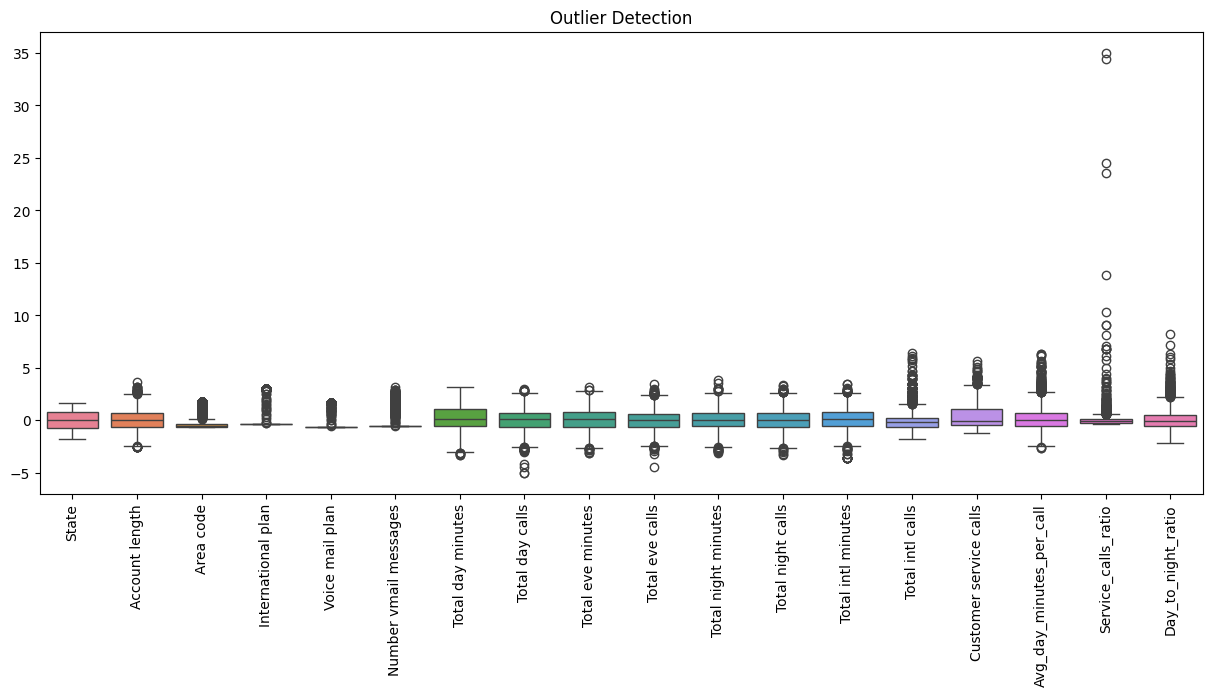

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.boxplot(data=pd.DataFrame(X_train_scaled_bal, columns=X.columns))
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()


In [66]:
corr_df = pd.DataFrame(X_train_scaled_bal, columns=X.columns)
corr_df["Churn"] = y_train_bal.values

corr_df.corr()["Churn"].sort_values(ascending=False)


Churn                       1.000000
International plan          0.311743
Total day minutes           0.266344
Customer service calls      0.257349
Avg_day_minutes_per_call    0.200485
Total intl minutes          0.137909
Day_to_night_ratio          0.103809
Total eve minutes           0.101245
Total night minutes         0.086286
Service_calls_ratio         0.070221
Account length              0.039180
State                       0.034268
Total day calls             0.025755
Total night calls           0.021850
Total eve calls            -0.011177
Area code                  -0.049987
Total intl calls           -0.142605
Number vmail messages      -0.179494
Voice mail plan            -0.191593
Name: Churn, dtype: float64

In [67]:
print(type(X_train))
print(type(X_test))


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [68]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    eval_metric="AUC",
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)


In [69]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97       456
           1       0.96      0.68      0.80        78

    accuracy                           0.95       534
   macro avg       0.96      0.84      0.88       534
weighted avg       0.95      0.95      0.95       534

ROC-AUC: 0.8814946018893388


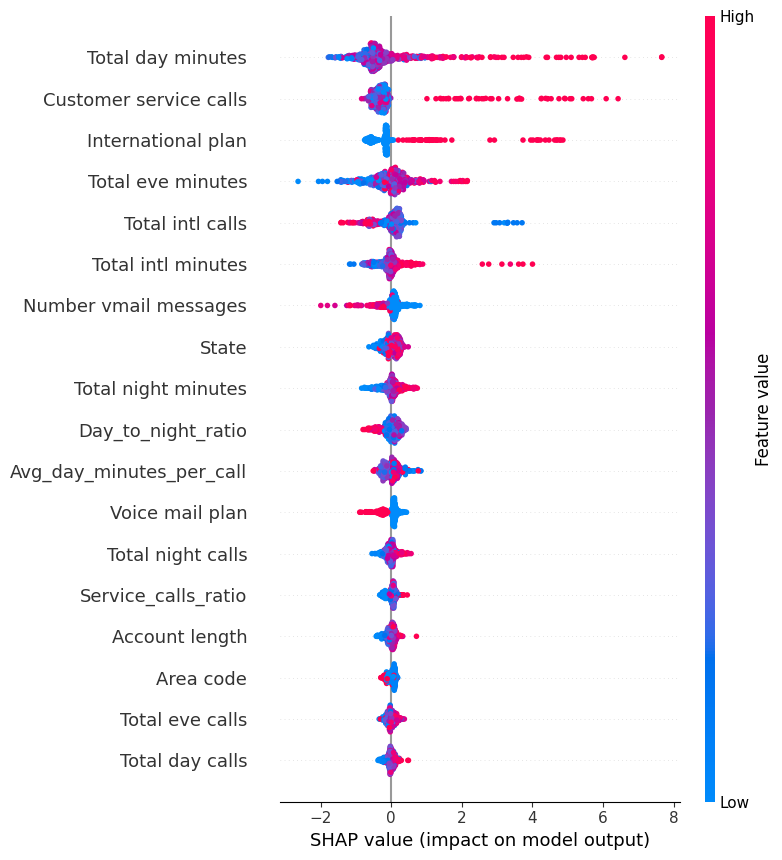

In [70]:
import shap

explainer = shap.TreeExplainer(cat)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


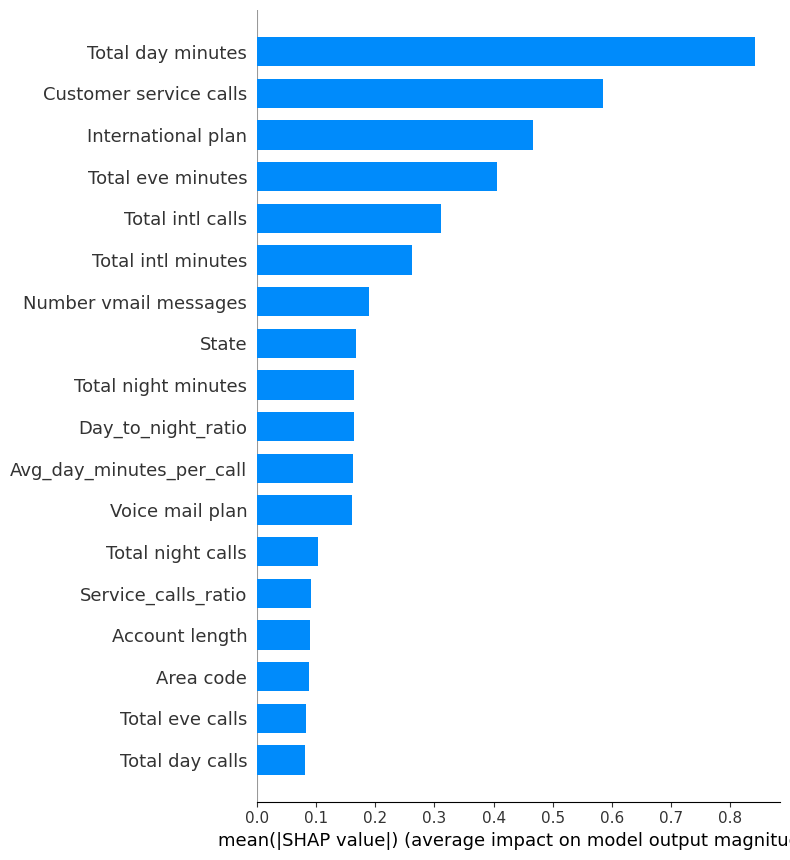

In [71]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


In [72]:
results = X_test.copy()

results["churn_probability"] = y_prob

results["risk_level"] = pd.cut(
    results["churn_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

results["risk_level"].value_counts()


risk_level
Low Risk       471
High Risk       50
Medium Risk     13
Name: count, dtype: int64

In [73]:
import joblib

# save trained model
joblib.dump(cat, "telecom_churn_model.pkl")

# save scaler
joblib.dump(scaler, "telecom_scaler.pkl")

# save encoders
joblib.dump(le, "state_encoder.pkl")
joblib.dump(le, "plan_encoder.pkl")

# save feature order
joblib.dump(X_train.columns.tolist(), "telecom_feature_names.pkl")

print("✅ Telecom model files saved successfully")


✅ Telecom model files saved successfully


In [74]:
import joblib

model = joblib.load("telecom_churn_model.pkl")
features = joblib.load("telecom_feature_names.pkl")


In [75]:
# take random customers
telecom_test = X_test.sample(5)

telecom_test


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Avg_day_minutes_per_call,Service_calls_ratio,Day_to_night_ratio
1927,6,120,408,1,0,0,202.0,123,184.3,78,176.0,89,7.4,2,2,1.629032,0.016529,1.141243
459,9,64,408,0,1,31,228.6,88,248.5,109,167.1,124,9.0,1,3,2.568539,0.046154,1.359905
894,50,106,415,1,1,26,270.3,111,215.2,90,254.0,133,14.4,7,1,2.413393,0.009346,1.060000
1841,23,46,408,0,0,0,156.4,105,185.5,98,226.7,96,11.8,3,1,1.475472,0.021277,0.686869
519,34,140,415,0,0,0,235.5,81,257.2,130,103.1,111,11.5,4,2,2.871951,0.014184,2.262248


In [76]:
cat_pred = cat.predict(telecom_test)
cat_prob = cat.predict_proba(telecom_test)

result = pd.DataFrame({
    "Churn_Prediction": cat_pred,
    "Churn_Probability": cat_prob[:,1]
})

result


,Churn_Prediction,Churn_Probability
0,1,0.929057
1,0,0.010022
2,1,0.814222
3,0,0.006970
4,0,0.071439


In [77]:
feature_names = X_train.columns
print(feature_names)

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total eve minutes', 'Total eve calls',
       'Total night minutes', 'Total night calls', 'Total intl minutes',
       'Total intl calls', 'Customer service calls',
       'Avg_day_minutes_per_call', 'Service_calls_ratio',
       'Day_to_night_ratio'],
      dtype='object')


In [78]:
telecom_sample = pd.DataFrame(
    [[
        12,     # State (label encoded)
        120,    # Account length
        408,    # Area code
        1,      # International plan
        0,      # Voice mail plan
        0,      # Number vmail messages
        210.5,  # Total day minutes
        110,    # Total day calls
        195.4,  # Total eve minutes
        90,     # Total eve calls
        180.3,  # Total night minutes
        95,     # Total night calls
        12.5,   # Total intl minutes
        3,      # Total intl calls
        4,      # Customer service calls
        1.91,   # Avg_day_minutes_per_call
        0.03,   # Service_calls_ratio
        1.17    # Day_to_night_ratio
    ]],
    columns=features
)


In [79]:
prob = model.predict_proba(telecom_sample)[0][1]
pred = int(prob >= 0.5)

print("Churn probability:", round(prob, 3))
print("Prediction:", pred)


Churn probability: 0.015
Prediction: 0


In [80]:
telecom_test_churn = pd.DataFrame(
    [[
        25,     # State (encoded number)
        15,     # Account length (very low tenure)
        408,    # Area code
        1,      # International plan (YES)
        0,      # Voice mail plan (NO)
        0,      # Number vmail messages
        320.0,  # Total day minutes (very high)
        140,    # Total day calls
        290.0,  # Total eve minutes
        130,    # Total eve calls
        260.0,  # Total night minutes
        120,    # Total night calls
        18.5,   # Total intl minutes (very high)
        7,      # Total intl calls
        6,      # Customer service calls (VERY IMPORTANT)
        2.28,   # Avg_day_minutes_per_call
        0.15,   # Service_calls_ratio (high)
        1.45    # Day_to_night_ratio
    ]],
    columns=features
)


In [81]:
prob = model.predict_proba(telecom_test_churn)[0][1]
pred = int(prob >= 0.5)

print("Churn probability:", round(prob, 3))
print("Prediction:", pred)

Churn probability: 0.964
Prediction: 1


In [82]:
import joblib

# Save trained model
joblib.dump(cat, "/kaggle/working/telecom_model.pkl")

# Save scaler
joblib.dump(scaler, "/kaggle/working/telecom_scaler.pkl")

# Save state encoder
joblib.dump(le, "/kaggle/working/telecom_state_encoder.pkl")

# Save feature order
joblib.dump(X_train.columns.tolist(), "/kaggle/working/telecom_features.pkl")

print("✅ All telecom model files saved successfully")


✅ All telecom model files saved successfully
